# 🧠 CASME II — Complete Fixed Pipeline
Swin-T Spatial + Motion Boosting Temporal + Focal + Triplet Loss + LOSO

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install -q timm opencv-python-headless openpyxl scikit-learn seaborn

In [3]:
import os, cv2, timm, numpy as np, pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## ✅ Config

In [4]:
class Config:
    ROOT_DIR       = '/content/drive/MyDrive/CASME2'   # <-- update if needed
    CROPPED_DIR    = os.path.join(ROOT_DIR, 'Cropped')
    CODING_FILE    = os.path.join(ROOT_DIR, 'CASME2-coding-20140508.xlsx')
    CLASSES_FILE   = os.path.join(ROOT_DIR, 'CASME2-ObjectiveClasses.xlsx')

    IMG_SIZE       = 224
    NUM_FRAMES     = 10
    NUM_CLASSES    = 5
    FEAT_DIM       = 256
    BATCH_SIZE     = 8
    NUM_WORKERS    = 2
    EPOCHS         = 50
    LR             = 1e-4
    WEIGHT_DECAY   = 1e-4
    TRIPLET_MARGIN = 0.3
    LAMBDA_TRIPLET = 0.5

    CLASSES = {
        'happiness':  0,
        'disgust':    1,
        'surprise':   2,
        'repression': 3,
        'others':     4,
    }

cfg = Config()

## 🔍 Inspect Excel + Folder Structure (run once)

In [5]:
coding  = pd.read_excel(cfg.CODING_FILE)
classes = pd.read_excel(cfg.CLASSES_FILE)
print('CODING  columns:', list(coding.columns))
print('CLASSES columns:', list(classes.columns))
print()
print(coding.head(3))
print()
print(classes.head(3))
print()
top = sorted(os.listdir(cfg.CROPPED_DIR))[:5]
print('Cropped top-level folders:', top)
print('Inside first folder:', os.listdir(os.path.join(cfg.CROPPED_DIR, top[0]))[:3])

CODING  columns: ['Subject', 'Filename', 'Unnamed: 2', 'OnsetFrame', 'ApexFrame', 'OffsetFrame', 'Unnamed: 6', 'Action Units', 'Estimated Emotion']
CLASSES columns: ['Subject', 'Filename', 'Objective Class']

   Subject  Filename  Unnamed: 2  OnsetFrame ApexFrame  OffsetFrame  \
0        1  EP02_01f         NaN          46        59           86   
1        1   EP03_02         NaN         131       139          161   
2        1   EP04_02         NaN          21        54           76   

   Unnamed: 6 Action Units Estimated Emotion  
0         NaN           12         happiness  
1         NaN           18            others  
2         NaN            4            others  

   Subject  Filename  Objective Class
0        1  EP02_01f                1
1        1   EP03_02                7
2        1   EP04_02                3

Cropped top-level folders: ['Cropped', 'sub01', 'sub02', 'sub03', 'sub04']
Inside first folder: ['sub25', 'sub26', 'sub24']


## ✅ Load Annotations

In [6]:
def load_annotations(config):
    coding  = pd.read_excel(config.CODING_FILE)
    classes = pd.read_excel(config.CLASSES_FILE)

    coding.columns  = [c.strip().lower() for c in coding.columns]
    classes.columns = [c.strip().lower() for c in classes.columns]

    # Standardise key columns to string
    for d in [coding, classes]:
        d['subject']  = d['subject'].astype(str).str.strip().str.zfill(2)
        d['filename'] = d['filename'].astype(str).str.strip()

    df = pd.merge(coding, classes, on=['subject', 'filename'], how='inner')
    print(f'Merged rows: {len(df)}')

    # 'estimated emotion' is column I in your Excel
    df['emotion_clean'] = df['estimated emotion'].astype(str).str.lower().str.strip()
    print('Unique emotion labels:', df['emotion_clean'].unique())

    df = df[df['emotion_clean'].isin(config.CLASSES.keys())].copy()
    df['label']     = df['emotion_clean']
    df['label_idx'] = df['label'].map(config.CLASSES)

    print(f'\n Kept {len(df)} sequences | {df["subject"].nunique()} subjects')
    print(df['label'].value_counts())
    return df

df = load_annotations(cfg)
df[['subject','filename','label','onsetframe','apexframe','offsetframe']].head()

Merged rows: 255
Unique emotion labels: ['happiness' 'others' 'disgust' 'repression' 'surprise' 'fear' 'sadness']

 Kept 246 sequences | 26 subjects
label
others        99
disgust       63
happiness     32
repression    27
surprise      25
Name: count, dtype: int64


,subject,filename,label,onsetframe,apexframe,offsetframe
0,01,EP02_01f,happiness,46,59,86
1,01,EP03_02,others,131,139,161
2,01,EP04_02,others,21,54,76
3,01,EP04_03,others,31,41,56
4,01,EP04_04,others,23,49,66


## ✅ Path Builder + Verification

In [7]:
def build_path(config, filename):
    """
    Filename: EP02_01f  ->  subject folder = EP02
    Full path: Cropped/EP02/EP02_01f
    """
    filename   = str(filename).strip()
    sub_folder = filename.split('_')[0]   # EP02_01f -> EP02
    return os.path.join(config.CROPPED_DIR, sub_folder, filename)

# Verify first 5 paths
print('--- Path verification ---')
for _, row in df.head(5).iterrows():
    p = build_path(cfg, row['filename'])
    print(f'EXISTS={os.path.exists(p)}  {p}')

--- Path verification ---
EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP02/EP02_01f
EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP03/EP03_02
EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP04/EP04_02
EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP04/EP04_03
EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP04/EP04_04


> If **EXISTS=False** — run this auto-detection cell to find correct format:

In [8]:
# Auto path detection — only run if EXISTS=False above
row   = df.iloc[0]
fname = str(row['filename'])
base  = cfg.CROPPED_DIR
for candidate in [
    os.path.join(base, fname),
    os.path.join(base, fname.split('_')[0], fname),
    os.path.join(base, f"sub{int(float(row['subject'])):02d}", fname),
    os.path.join(base, f"EP{int(float(row['subject'])):02d}", fname),
]:
    print(f'EXISTS={os.path.exists(candidate)}  {candidate}')

EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP02_01f
EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP02/EP02_01f
EXISTS=True  /content/drive/MyDrive/CASME2/Cropped/sub01/EP02_01f
EXISTS=False  /content/drive/MyDrive/CASME2/Cropped/EP01/EP02_01f


## ✅ Frame Loading + Motion Boosting

In [9]:
def load_frames(folder_path, target_size=224):
    folder = Path(folder_path)
    if not folder.exists():
        return []
    exts  = ('.jpg', '.jpeg', '.png', '.bmp')
    paths = sorted([p for p in folder.iterdir()
                    if p.suffix.lower() in exts])
    frames = []
    for p in paths:
        img = cv2.imread(str(p))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (target_size, target_size))
        frames.append(img)
    return frames

def compute_optical_flow(f1, f2):
    g1 = cv2.cvtColor(f1, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(f2, cv2.COLOR_RGB2GRAY)
    return cv2.calcOpticalFlowFarneback(g1, g2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

def extract_motion(frames, onset, apex, n=10, sz=224):
    win = frames[onset:apex+1] if apex > onset else frames
    if len(win) < 2:
        return np.zeros((2*n, sz, sz), dtype=np.float32)
    idx   = np.linspace(0, len(win)-2, n, dtype=int)
    flows = []
    for i in idx:
        fl  = compute_optical_flow(win[i], win[i+1])
        fl /= (np.max(np.abs(fl)) + 1e-6)
        flows.append(fl.transpose(2, 0, 1))
    return np.concatenate(flows, axis=0).astype(np.float32)

# Quick visualisation
row    = df.iloc[0]
frames = load_frames(build_path(cfg, row['filename']), cfg.IMG_SIZE)
print(f'Frames loaded: {len(frames)}')
if frames:
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, fi, title in zip(axes, [0, len(frames)//2, -1],
                              ['First', 'Apex', 'Last']):
        ax.imshow(frames[fi]); ax.set_title(f'{title} | {row["label"]}'); ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No frames found — fix build_path() first')

Frames loaded: 0
No frames found — fix build_path() first


## ✅ Dataset + DataLoaders

In [10]:
class CASME2Dataset(Dataset):
    def __init__(self, df, config, augment=False):
        self.df  = df.reset_index(drop=True)
        self.cfg = config
        aug = [
            T.ToPILImage(),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ]
        val = [
            T.ToPILImage(),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ]
        self.tfm = T.Compose(aug if augment else val)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        path   = build_path(self.cfg, row['filename'])
        frames = load_frames(path, self.cfg.IMG_SIZE)

        # Fallback: blank frame if folder missing
        if not frames:
            sz = self.cfg.IMG_SIZE
            blank = np.zeros((sz, sz, 3), dtype=np.uint8)
            spatial  = self.tfm(blank)
            temporal = torch.zeros(self.cfg.NUM_FRAMES * 2, sz, sz)
            return spatial, temporal, int(row['label_idx'])

        n = len(frames)
        # onsetframe / apexframe / offsetframe  (lowercase after .lower() in load_annotations)
        onset  = max(0, min(int(float(row.get('onsetframe',  0))),    n-1))
        apex   = max(0, min(int(float(row.get('apexframe',   n//2))), n-1))

        spatial  = self.tfm(frames[apex])
        temporal = torch.tensor(
            extract_motion(frames, onset, apex,
                           self.cfg.NUM_FRAMES, self.cfg.IMG_SIZE))
        return spatial, temporal, int(row['label_idx'])


def loso_loaders(df, val_sub, cfg):
    val_sub = str(val_sub).zfill(2)
    train_df = df[df['subject'] != val_sub]
    val_df   = df[df['subject'] == val_sub]
    kw = dict(batch_size=cfg.BATCH_SIZE,
              num_workers=cfg.NUM_WORKERS,
              pin_memory=True)
    train_loader = DataLoader(CASME2Dataset(train_df, cfg, augment=True),
                              shuffle=True,  **kw)
    val_loader   = DataLoader(CASME2Dataset(val_df,   cfg, augment=False),
                              shuffle=False, **kw)
    print(f'Subject {val_sub} → train: {len(train_df)} | val: {len(val_df)}')
    return train_loader, val_loader

# Shape check
tl, vl = loso_loaders(df, df['subject'].unique()[0], cfg)
sp, tm, lb = next(iter(tl))
print('Spatial :', sp.shape)    # (B, 3, 224, 224)
print('Temporal:', tm.shape)    # (B, 20, 224, 224)
print('Labels  :', lb)

Subject 01 → train: 237 | val: 9
Spatial : torch.Size([8, 3, 224, 224])
Temporal: torch.Size([8, 20, 224, 224])
Labels  : tensor([1, 1, 4, 4, 1, 1, 4, 1])


## ✅ Model — Swin-T + Motion CNN + Cross-Attention Fusion

In [11]:
class SpatialStream(nn.Module):
    """Swin-Tiny pretrained on ImageNet → (B, FEAT_DIM)"""
    def __init__(self, feat_dim=256):
        super().__init__()
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True, num_classes=0)
        self.proj = nn.Sequential(
            nn.LayerNorm(self.backbone.num_features),
            nn.Linear(self.backbone.num_features, feat_dim),
            nn.GELU())
    def forward(self, x):
        return self.proj(self.backbone(x))


class MotionBoostingCNN(nn.Module):
    """4-block CNN on stacked optical-flow volume → (B, FEAT_DIM)"""
    def __init__(self, in_ch, feat_dim=256):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch,  64,  3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.GELU(),
            nn.Conv2d(64,  128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 512, 3, stride=2, padding=1), nn.BatchNorm2d(512), nn.GELU(),
            nn.AdaptiveAvgPool2d(1))
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, feat_dim),
            nn.GELU())
    def forward(self, x):
        return self.proj(self.enc(x))


class CrossAttentionFusion(nn.Module):
    """Each stream attends to the other, outputs concatenated (B, 2*D)"""
    def __init__(self, d=256, heads=4):
        super().__init__()
        self.attn_s = nn.MultiheadAttention(d, heads, batch_first=True)
        self.attn_t = nn.MultiheadAttention(d, heads, batch_first=True)
        self.norm_s = nn.LayerNorm(d)
        self.norm_t = nn.LayerNorm(d)
    def forward(self, fs, ft):
        fs = fs.unsqueeze(1); ft = ft.unsqueeze(1)
        fs2, _ = self.attn_s(fs, ft, ft)
        ft2, _ = self.attn_t(ft, fs, fs)
        return torch.cat([self.norm_s(fs + fs2).squeeze(1),
                          self.norm_t(ft + ft2).squeeze(1)], dim=-1)


class MicroExpressionModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        D = config.FEAT_DIM
        self.spatial  = SpatialStream(D)
        self.temporal = MotionBoostingCNN(config.NUM_FRAMES * 2, D)
        self.fusion   = CrossAttentionFusion(D)
        self.head     = nn.Sequential(
            nn.Linear(D*2, D), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(D, config.NUM_CLASSES))
    def forward(self, sp, tm):
        fused  = self.fusion(self.spatial(sp), self.temporal(tm))
        logits = self.head(fused)
        return logits, fused   # fused used for triplet loss

# Shape test
model = MicroExpressionModel(cfg).to(device)
logits, emb = model(sp.to(device), tm.to(device))
print('Logits   :', logits.shape)   # (B, 5)
print('Embedding:', emb.shape)      # (B, 512)
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Logits   : torch.Size([8, 5])
Embedding: torch.Size([8, 512])
Total params: 30,071,743


## ✅ Focal Loss + Triplet Loss

In [12]:
class FocalLoss(nn.Module):
    """FL = -alpha_t * (1 - p_t)^gamma * log(p_t)  handles class imbalance"""
    def __init__(self, gamma=2.0, num_classes=5):
        super().__init__()
        self.gamma = gamma
        self.register_buffer('alpha', torch.ones(num_classes))
    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        pt  = torch.exp(-ce)
        at  = self.alpha[targets]
        return (at * (1 - pt) ** self.gamma * ce).mean()


class TripletLoss(nn.Module):
    """Batch-hard mining — weakly supervised, good for small ME datasets"""
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin
    def forward(self, emb, labels):
        B    = emb.size(0)
        dist = torch.cdist(emb, emb, p=2)
        losses = []
        arange = torch.arange(B, device=labels.device)
        for i in range(B):
            pm = (labels == labels[i]) & (arange != i)
            nm = labels != labels[i]
            if pm.sum() == 0 or nm.sum() == 0: continue
            losses.append(F.relu(
                dist[i][pm].max() - dist[i][nm].min() + self.margin))
        return torch.stack(losses).mean() if losses else \
               torch.tensor(0., device=emb.device)


focal_loss   = FocalLoss(gamma=2.0, num_classes=cfg.NUM_CLASSES).to(device)
triplet_loss = TripletLoss(margin=cfg.TRIPLET_MARGIN)
print('Losses ready')

Losses ready


## ✅ Train + Eval Functions

In [13]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for sp, tm, lb in loader:
        sp, tm, lb = sp.to(device), tm.to(device), lb.to(device)
        optimizer.zero_grad()
        logits, emb = model(sp, tm)
        loss = focal_loss(logits, lb) + cfg.LAMBDA_TRIPLET * triplet_loss(emb, lb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == lb).sum().item()
        total      += lb.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    for sp, tm, lb in loader:
        sp, tm, lb = sp.to(device), tm.to(device), lb.to(device)
        logits, _  = model(sp, tm)
        preds      = logits.argmax(1)
        correct   += (preds == lb).sum().item()
        total     += lb.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(lb.cpu().tolist())
    return correct / total, all_preds, all_labels

print('Functions ready')

Functions ready


## ✅ LOSO Cross-Validation

In [14]:
subjects = sorted(df['subject'].unique())
all_acc, all_preds_global, all_labels_global = [], [], []

for val_sub in subjects:
    print(f'\n━━━ LOSO: val subject = {val_sub} ━━━')
    train_loader, val_loader = loso_loaders(df, val_sub, cfg)

    if len(val_loader.dataset) == 0:
        print('  No val samples, skipping.')
        continue

    model     = MicroExpressionModel(cfg).to(device)
    optimizer = AdamW(model.parameters(),
                      lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)

    best_acc, best_state = 0.0, None

    for epoch in range(1, cfg.EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        val_acc, _, _   = evaluate(model, val_loader)
        scheduler.step()

        if val_acc > best_acc:
            best_acc  = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f'  Ep {epoch:3d} | loss {tr_loss:.4f} '
                  f'| train {tr_acc:.3f} | val {val_acc:.3f}')

    model.load_state_dict(best_state)
    final_acc, preds, labels = evaluate(model, val_loader)
    all_acc.append(final_acc)
    all_preds_global.extend(preds)
    all_labels_global.extend(labels)
    print(f'  Best val acc: {final_acc:.4f}')

print(f'\n LOSO Mean Accuracy: {np.mean(all_acc):.4f} +/- {np.std(all_acc):.4f}')


━━━ LOSO: val subject = 01 ━━━
Subject 01 → train: 237 | val: 9


  Ep  10 | loss 1.0970 | train 0.388 | val 0.667
  Ep  20 | loss 1.0959 | train 0.388 | val 0.667
  Ep  30 | loss 1.0661 | train 0.384 | val 0.667
  Ep  40 | loss 1.0655 | train 0.388 | val 0.667
  Ep  50 | loss 1.0672 | train 0.397 | val 0.667
  Best val acc: 0.6667

━━━ LOSO: val subject = 02 ━━━
Subject 02 → train: 233 | val: 13
  Ep  10 | loss 1.0603 | train 0.399 | val 0.308
  Ep  20 | loss 1.0309 | train 0.399 | val 0.308
  Ep  30 | loss 1.0619 | train 0.412 | val 0.308
  Ep  40 | loss 1.0384 | train 0.403 | val 0.308
  Ep  50 | loss 1.0173 | train 0.403 | val 0.308
  Best val acc: 0.3077

━━━ LOSO: val subject = 03 ━━━
Subject 03 → train: 239 | val: 7
  Ep  10 | loss 1.1172 | train 0.389 | val 0.286
  Ep  20 | loss 1.0720 | train 0.397 | val 0.286
  Ep  30 | loss 1.0640 | train 0.397 | val 0.286
  Ep  40 | loss 1.0528 | train 0.406 | val 0.286
  Ep  50 | loss 1.0525 | train 0.406 | val 0.286
  Best val acc: 0.2857

━━━ LOSO: val subject = 04 ━━━
Subject 04 → train: 241 | val: 5


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

## ✅ Results — Classification Report + Confusion Matrix

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   happiness       0.00      0.00      0.00        16
     disgust       0.60      0.12      0.20        25
    surprise       0.00      0.00      0.00        15
  repression       0.00      0.00      0.00        11
      others       0.49      0.97      0.65        63

    accuracy                           0.49       130
   macro avg       0.22      0.22      0.17       130
weighted avg       0.35      0.49      0.35       130



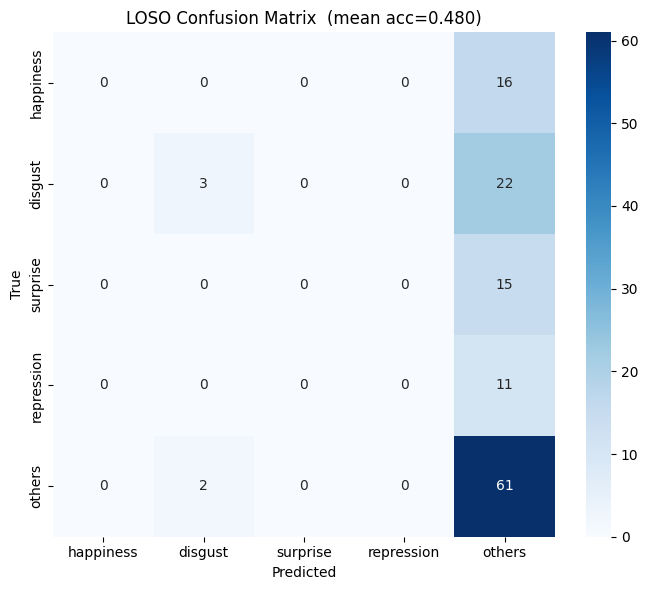

In [15]:
class_names = list(cfg.CLASSES.keys())
print(classification_report(
    all_labels_global, all_preds_global, target_names=class_names))

cm = confusion_matrix(all_labels_global, all_preds_global)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'LOSO Confusion Matrix  (mean acc={np.mean(all_acc):.3f})')
plt.tight_layout()
plt.show()